In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from param_estim_it4_alteration import run_mcmc


C:\Users\Træning 3\AppData\Local\Temp\ipykernel_23912\3323125248.py:28: RuntimeWarning: overflow encountered in exp
  b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))


These are the B1 vals:  [-0.00000000e+00  1.87665875e-05  1.87665875e-05 ...  1.87665875e-05
  1.87665875e-05  1.87665875e-05] This is the length:  100000
-0.0
51.254870489723494
98.67655692261786
142.54967841910525
183.13977410389967
220.69251280822465
255.43517996393794
287.57805323365835
317.31567520128425
344.8280308284871


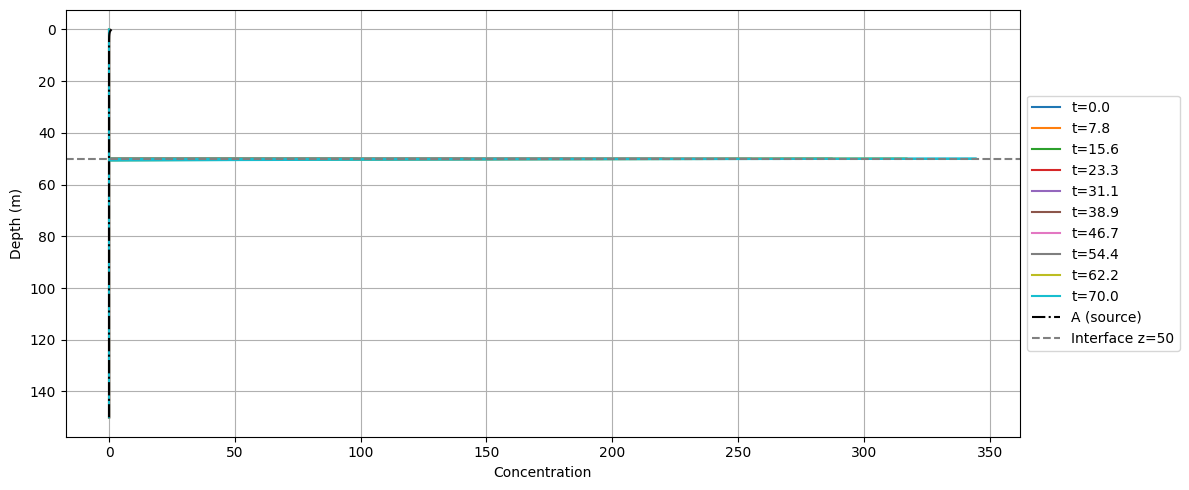

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#alpha = 9.156
#Da    = 1.13
#lambda_ = np.sqrt(alpha / Da)
#kappa   = 0.023
#u1      = 82665.16
#u2      = 0.0059

alpha = np.mean([1.74, 1.30, 0.87]) 
Da = 1
lambda_ = np.sqrt(alpha/Da)
kappa = 1.42*10**(-2)
u1= 3.65*10**5
u2= 0.01
C = 5.0 + 1.0

t       = np.linspace(0, 70, 100_000)
z1      = np.linspace(0,  50, 50_000)
z2_phys = np.linspace(50, 150, 100_000)


# ── B1 ──────────────────────────────────────────────────────────────────────
def B_func51(z, t_val, u1, alpha, lambda_, kappa, C):
    a  = kappa - lambda_ * u1
    b_ss  = (alpha / a) * C * np.exp(-lambda_ * z) * (1 - np.exp(-a * z / u1))
    b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))
    return np.where(z <= u1 * t_val, b_ss, b_tr)


# ── B1 evaluated exactly at z = 50 ──────────────────────────────────────────
def B1_at_50(t_array, u1, alpha, lambda_, kappa, C):
    """Simply evaluate B_func51 at z=50 for each t — no clamp."""
    return B_func51(50.0, t_array, u1, alpha, lambda_, kappa, C)


# ── Interface ODE — convolution integral ─────────────────────────────────────
def interface_M(t_array, u1, u2, alpha, lambda_, kappa, C):
    """
    M(t) = ∫₀ᵗ  u1 · B1(50, τ) · exp(−u2·(t−τ))  dτ

    Computed incrementally so we only do O(N) work instead of O(N²).
    Update rule (trapezoidal, step by step):
        M(t_{n+1}) = M(t_n)·exp(−u2·Δt)
                   + Δt·u1·½·[B1(50,t_n)·exp(−u2·Δt) + B1(50,t_{n+1})]
    This is the exact integral assuming B1 is linear between steps.
    """
    t_array = np.asarray(t_array)
    M       = np.zeros_like(t_array)
    B1_vals = B1_at_50(t_array, u1, alpha, lambda_, kappa, C)
    print("These are the B1 vals: ", B1_vals, "This is the length: ", len(B1_vals))

    for i in range(1, len(t_array)):
        dt_i   = t_array[i] - t_array[i - 1]
        decay  = np.exp(-u2 * dt_i)
        # trapezoidal on the integrand f(τ) = u1·B1(50,τ) between t_{i-1} and t_i
        f_prev = u1 * B1_vals[i - 1]
        f_curr = u1 * B1_vals[i]
        M[i]   = M[i - 1] * decay + dt_i * 0.5 * (f_prev * decay + f_curr)

    return M


# ── B2 ──────────────────────────────────────────────────────────────────────
def B_func52(z2_phys, t_val, u2, alpha, lambda_, t_array, kappa, M_vals, C):
    a2 = kappa - lambda_ * u2
    z2 = z2_phys - 50.0        # shifted coordinate (0 at interface)

    # Characteristic travel time from interface to z
    tau_travel = z2 / u2

    # Retarded time (clipped to [0, t_val] and to array bounds)
    tau = np.clip(t_val - tau_travel, 0.0, t_array[-1])

    # M interpolated at the retarded time
    M_tau = np.interp(tau, t_array, M_vals)

    # Branch 1: characteristic has arrived (z2 ≤ u2·t_val)
    b1 = ( (alpha / a2) * C * np.exp(-lambda_ * z2_phys)
           + (M_tau - (alpha / a2) * C * np.exp(-lambda_ * 50.0))
             * np.exp(-kappa * tau_travel) )

    # Branch 2: characteristic has not yet arrived
    b2 = (alpha / a2) * C * np.exp(-lambda_ * z2_phys) * (1.0 - np.exp(-a2 * t_val))

    return np.where(z2 <= u2 * t_val, b1, b2)


# ── Compute M once ───────────────────────────────────────────────────────────
M_vals = interface_M(t, u1, u2, alpha, lambda_, kappa, C)

# ── Plot ─────────────────────────────────────────────────────────────────────
z_full = np.concatenate([z1, z2_phys])
A_full = np.exp(-lambda_ * z_full)

indices   = np.linspace(0, len(t) - 1, 10, dtype=int)
t_sampled = t[indices]

plt.figure(figsize=(12, 5))
for ti in t_sampled:
    B1 = B_func51(z1, ti, u1, alpha, lambda_, kappa, C)
    B2 = B_func52(z2_phys, ti, u2, alpha, lambda_, t, kappa, M_vals, C)
    B  = np.concatenate([B1, B2])
    print(max(B))
    plt.plot(B, z_full, label=f"t={ti:.1f}")

plt.plot(A_full, z_full, 'k-.', label="A (source)")
plt.axhline(50, linestyle='--', color='grey', label="Interface z=50")
plt.gca().invert_yaxis()
plt.xlabel("Concentration")
plt.ylabel("Depth (m)")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [10]:
print("Alpha", alpha, "Da", Da, "kappa", kappa, "U1", u1, "U2", u2, "C", C)

Alpha 1.3033333333333335 Da 1 kappa 0.014199999999999999 U1 365000.0 U2 0.01 C 6.0


5.0
5.0
5.0
36.76310835357045
68.50925586690884
97.88098070219145
125.05587752623943
150.19825675710143
173.4601481612306
194.9821738428031


c:\Users\Træning 3\OneDrive - Roskilde Universitet\12. semester\Speciale - General\Numerik\Scripts\MCMC\it4\it4_anal_solver.py:16: RuntimeWarning: overflow encountered in exp
  b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))


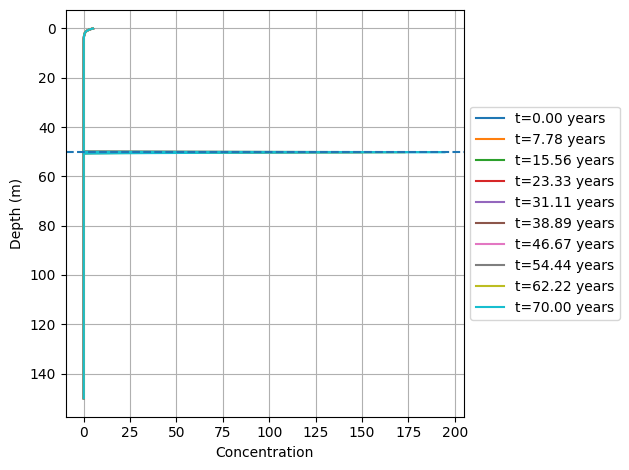

In [11]:
# plot
from it4_anal_solver import B_funky
C = 5
zeta = np.linspace(0, 150, 1000)
for i in range(len(t_sampled)):
    ti = t_sampled[i]
    t = np.linspace(0, ti, 1000)  # NEW time array up to current ti
    full = B_funky(zeta, ti, u1, u2, alpha, Da, kappa, C, t)
    plt.plot(full, zeta, label=f"t={ti:.2f} years")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    print(max(full))

    #print(f"Max error at t={ti:.2f} years: {np.max(error)}")
plt.ylabel("Depth (m)")
plt.xlabel("Concentration")
plt.axhline(y=50, linestyle='--',label="Seabed")
plt.gca().invert_yaxis()
plt.grid()

plt.tight_layout()
#plt.ylim(5,0)

plt.show()


In [12]:

L = 150.0

water_raw = [
    (2.5,   3.5667891682785307),
    (7.5,   2.6969926716060204),
    (12.5,  0.9080153525061379),
    (17.5,  0.5380893150797977),
    (27.5,  0.15000000000000002),
    (32.5,  0.17777777777777778),
    (42.5,  0.07500000000000001),
    (47.5,  0.1),
]
sediment_raw = [   # (bin_centre_cm, concentration)
    (0.0125,               634.7414656833154),
    (0.037500000000000006, 478.3568408220815),
    (0.0625,               970.1680149695655),
    (0.08750000000000001,  2343.5408338909124),
    (0.1125,               1420.2905042168202),
    (0.1375,               1237.2282190132125),
    (0.16250000000000003,  1026.581643277907),
    (0.1875,               299.62609220263096),
    (0.21250000000000002,  681.4776292062617),
    (0.2375,               458.20696863375105),
    (0.2625,               422.2530388157952),
    (0.3125,               640.1515738798312),
    (0.3875,               63.55031042845192),
    (0.41250000000000003,  187.55853823063677),
    (0.48750000000000004,  30.846954308574094),
    (0.5375000000000001,   30.516169700062356),
    (0.6125,               17.81769496827207),
]

water_z   = np.array([r[0]                for r in water_raw])
water_val = np.array([r[1]                for r in water_raw])
sed_z     = np.array([r[0] + 50.0 for r in sediment_raw])  # cm→m + offset
sed_val   = np.array([r[1]                for r in sediment_raw])

# Zero-padding: penalise mass past the last observed depth
pad_z   = np.arange(sed_z[-1] + 0.5, L + 0.5, 10)
pad_val = np.zeros(len(pad_z))

obs_z   = np.concatenate([water_z, sed_z, pad_z])
obs_val = np.concatenate([water_val, sed_val, pad_val])
# --- fixed solver inputs ---
t_final = 70.0
t_array = np.linspace(0, t_final, 2000)
z_grid  = np.linspace(0, 150, 2000)


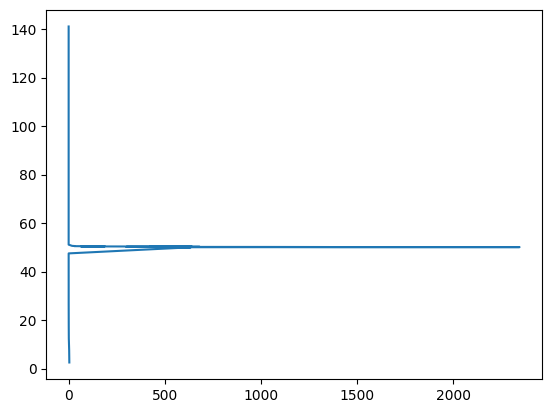

In [13]:
plt.plot(obs_val, obs_z)

In [18]:
from param_estim_it4_alteration import run_mcmc
import numpy as np
C = 60
init_p = {
    'z_grid':  z_grid,
    't':       t_final,
    'Da':      Da,
    'u1':      u1,
    'u2':      u2,
    'C':      C,
    't_array': t_array,
    'alpha':   alpha,
    
}

# --- parameters to estimate ---
param_cfg = {
    #'alpha':   {'init': alpha,              'sigma': 0.1, 'lo': 1e-4,  'hi': 2000.0,  'proposal': 'uniform'},
    #'C':      {'init': C,               'sigma': 0.5, 'lo': 1e-4,  'hi': 20_000,  'proposal': 'uniform'},
    'kappa':   {'init': kappa*10,         'sigma': 0.05, 'lo': 1e-6,  'hi': 20_000,   'proposal': 'uniform'},
    #'u1':       {'init': u1,   'sigma': 100, 'lo': 100,  'hi': 10**10,   'proposal': 'uniform'},
    #'u2':       {'init': u2,    'sigma': 0.01, 'lo': 1e-6,  'hi': 10.0,   'proposal': 'uniform'},
    'Da':      {'init': Da*64.84,            'sigma': 1, 'lo': 1e-6,  'hi': 10_000,   'proposal': 'uniform'}
}

other_weights = np.concatenate([
    water_val / np.max(water_val),
    sed_val   / np.max(sed_val),
    np.ones_like(pad_z)*0.5
])

other_weights = other_weights + 0.5
other_weights = other_weights/np.max(other_weights)

# --- run ---
final_state, saved_path = run_mcmc(
    obs_z          = obs_z,
    obs_val        = obs_val,
    init_p         = init_p,
    param_cfg      = param_cfg,
    num_iterations = 5_000_000,
    output_name    = f'fixed_C_5mio_its_random_inits_Da_kappa.h5',
    weights        = other_weights
)


c:\Users\Træning 3\OneDrive - Roskilde Universitet\12. semester\Speciale - General\Numerik\Scripts\MCMC\it4\it4_anal_solver.py:16: RuntimeWarning: overflow encountered in exp
  b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))


  iter      0  cost=441.7698  accept rate=0.00
  iter  10000  cost=50.5711  accept rate=0.27
  iter  20000  cost=51.0014  accept rate=0.27
  iter  30000  cost=51.6394  accept rate=0.26
  iter  40000  cost=50.9475  accept rate=0.26
  iter  50000  cost=51.5816  accept rate=0.26
  iter  60000  cost=50.1881  accept rate=0.26
  iter  70000  cost=51.1650  accept rate=0.26
  iter  80000  cost=50.4523  accept rate=0.26
  iter  90000  cost=50.3012  accept rate=0.26
  iter 100000  cost=52.1579  accept rate=0.26
  iter 110000  cost=50.4904  accept rate=0.26
  iter 120000  cost=50.5167  accept rate=0.26
  iter 130000  cost=52.5669  accept rate=0.26
  iter 140000  cost=51.0223  accept rate=0.26
  iter 150000  cost=50.7474  accept rate=0.26
  iter 160000  cost=50.2827  accept rate=0.26
  iter 170000  cost=51.3642  accept rate=0.26
  iter 180000  cost=50.2607  accept rate=0.26
  iter 190000  cost=51.6619  accept rate=0.26
  iter 200000  cost=51.4699  accept rate=0.26
  iter 210000  cost=51.7559  acce

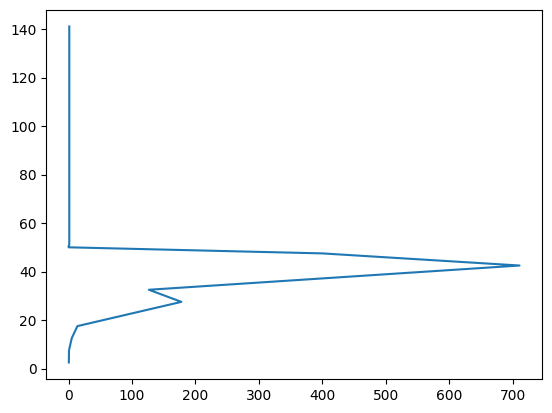

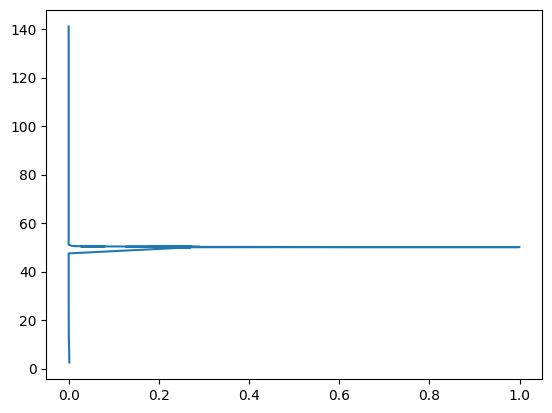

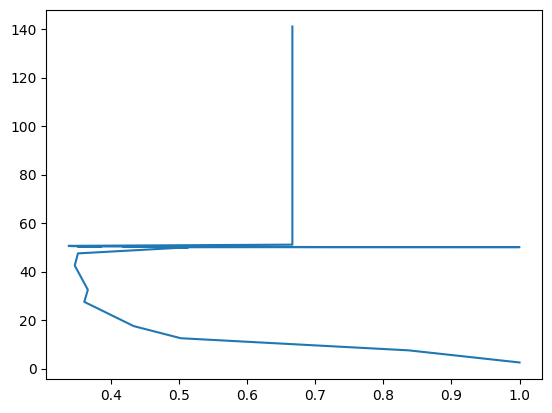

np.float64(0.33840193002275387)

In [15]:
sigma_obs    = np.where(obs_val > 0, 0.5 * obs_val, 1.0)
weights_real = 1.0 / sigma_obs**2
plt.plot(weights_real, obs_z)
plt.show()

weights_real = obs_val / np.max(obs_val)
plt.plot(weights_real, obs_z)
plt.show()

other_weights = np.concatenate([
    water_val / np.max(water_val),
    sed_val   / np.max(sed_val),
    np.ones_like(pad_z)*0.5
])

other_weights = other_weights + 0.5
other_weights = other_weights/np.max(other_weights)
plt.plot(other_weights, obs_z)
plt.show()

min(other_weights)


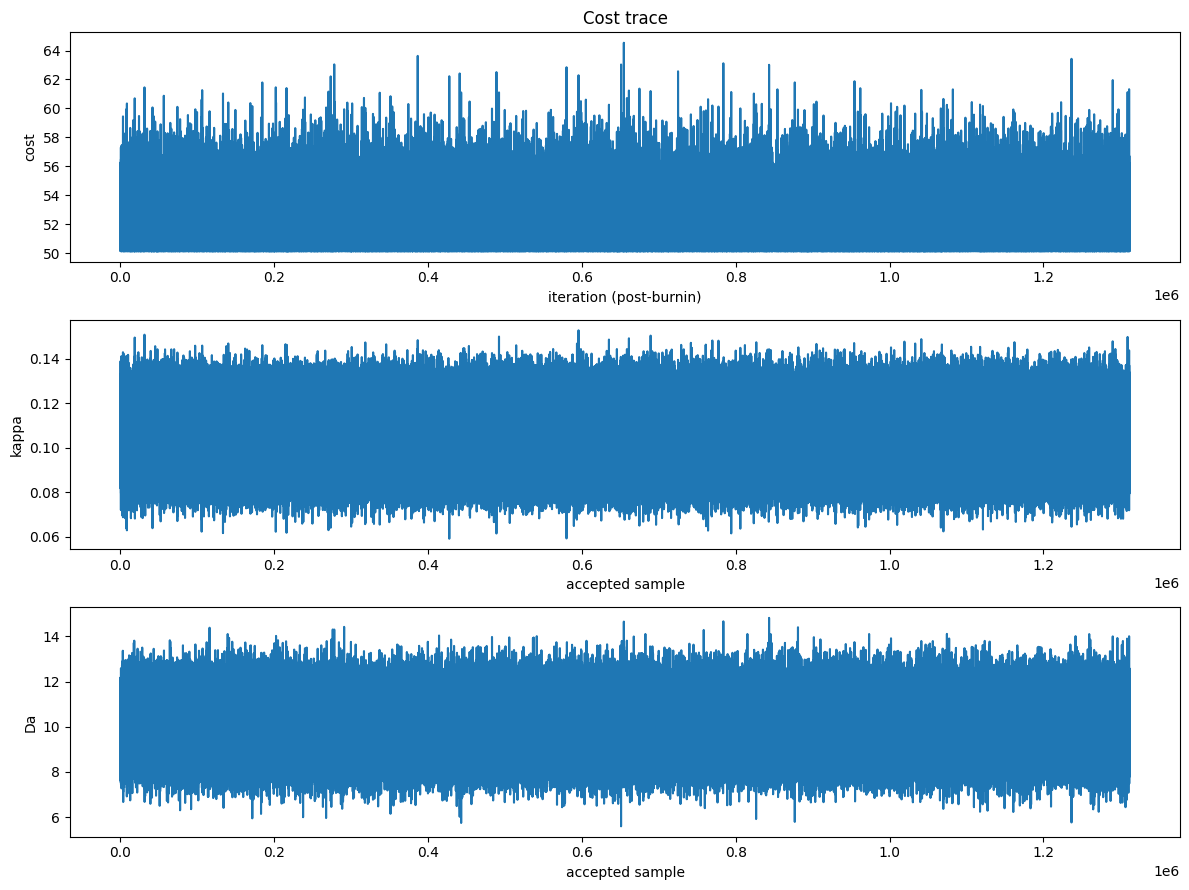

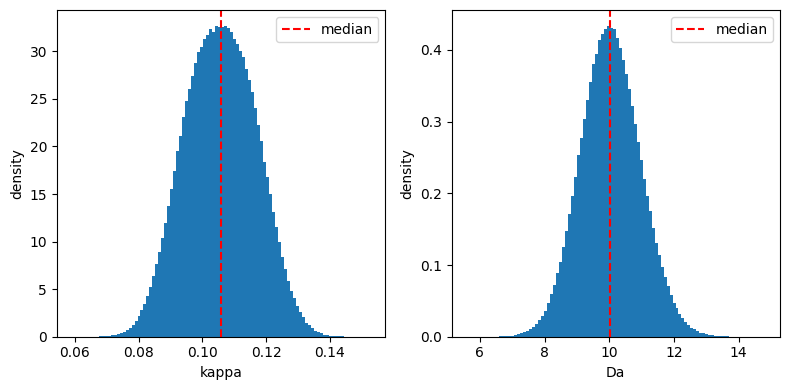

Posterior summaries (95% CI):
  kappa     : median=0.1057  95% CI=[0.08469, 0.1267]
  Da        : median=10.03  95% CI=[8.272, 11.9]


In [17]:
from param_estim_it4_alteration import load_chain
saved_path = "Idealized_param_set_chain_Da_kappa_C_nummer_GoodWeights_5mio_its_26_05_18_15_17.h5"
saved_path = "fixed_C_5mio_its_26_05_19_22_33.h5"
chain, costs, names, _ = load_chain(saved_path, burnin=500)

# --- Cost trace ---
fig, axes = plt.subplots(len(names) + 1, 1, figsize=(12, 3 * (len(names) + 1)), sharex=False)

axes[0].plot(costs)
axes[0].set_ylabel('cost')
axes[0].set_xlabel('iteration (post-burnin)')
axes[0].set_title('Cost trace')

# --- Parameter traces (accepted samples) ---
for i, name in enumerate(names):
    axes[i + 1].plot(chain[:, i])
    axes[i + 1].set_ylabel(name)
    axes[i + 1].set_xlabel('accepted sample')

plt.tight_layout()
plt.show()

# --- Marginal histograms ---
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4))
for i, name in enumerate(names):
    axes[i].hist(chain[:, i], bins=100, density=True)
    axes[i].axvline(np.median(chain[:, i]), color='r', linestyle='--', label='median')
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('density')
    axes[i].legend()

plt.tight_layout()
plt.show()

# --- Posterior summaries ---
print("Posterior summaries (95% CI):")
for i, name in enumerate(names):
    med = np.median(chain[:, i])
    lo, hi = np.percentile(chain[:, i], [2.5, 97.5])
    print(f"  {name:10s}: median={med:.4g}  95% CI=[{lo:.4g}, {hi:.4g}]")

In [ ]:
#combichains = np.concatenate([chain1, chain])
#combicosts = np.concatenate([costs1, costs])

combichains = chain


In [ ]:
#combichains = np.concatenate([chain1, chain])
#combicosts = np.concatenate([costs1, costs])



283.88773772351453 4.982018308263996 0.11601261066939836


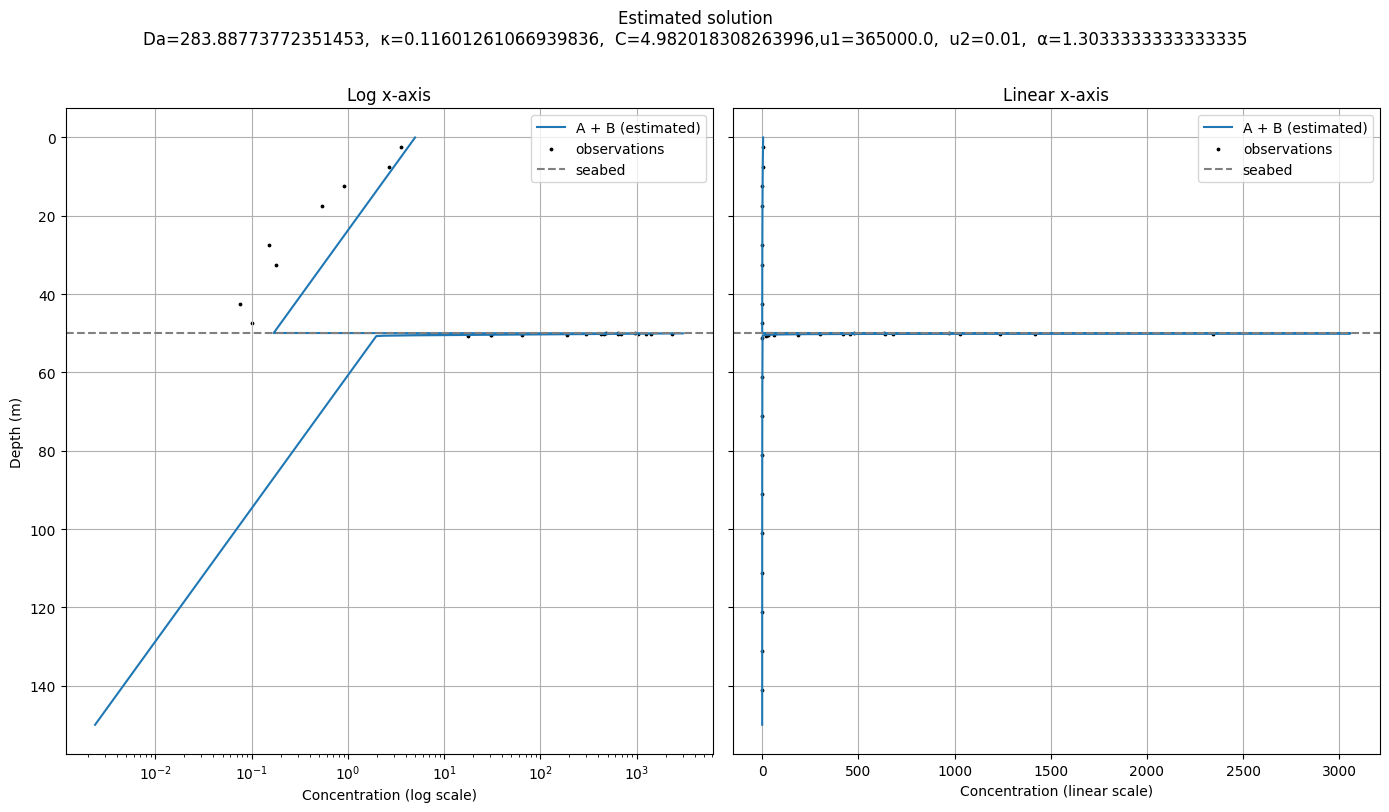

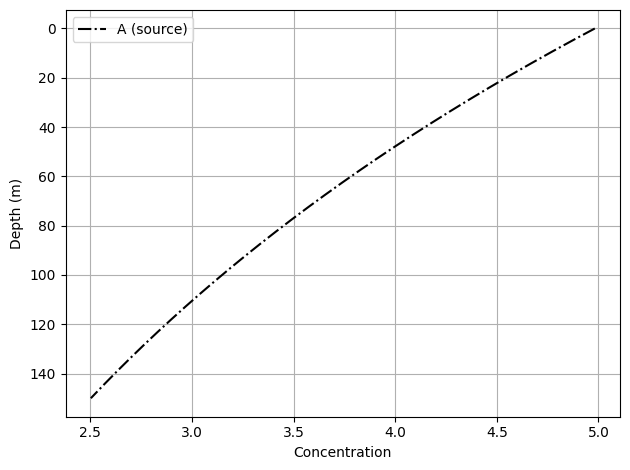

3.96015932775126


In [ ]:
combichains = chain

# --- Estimated solution vs observations ---
alpha_est  = alpha#np.median(chain[:, names.index('alpha')])
Da_est     = np.median(combichains[:, names.index('Da')])
C_est     = np.median(combichains[:, names.index('C')])
kappa_est  = np.median(combichains[:, names.index('kappa')])
u1_est     = u1#np.median(chain[:, names.index('u1')])
u2_est     = u2#np.median(chain[:, names.index('u2')])
print(Da_est, C_est, kappa_est)

z_plot  = np.linspace(0, 150, 1500)
t_final = 70.0
t_plot  = np.linspace(0, t_final, 1000)
total_est   = B_funky(z_plot, t_final, u1_est, u2_est, alpha_est, Da_est, kappa_est, C_est, t_plot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

title_str = (
    f'Da={Da_est},  κ={kappa_est},  C={C_est},'
    f'u1={u1_est},  u2={u2_est},  α={alpha_est}'
)

# --- Left: log x ---
ax1.plot(total_est, z_plot, label='A + B (estimated)', color='tab:blue')
ax1.scatter(obs_val, obs_z, color='k', label='observations', s=3)
ax1.axhline(y=50, linestyle='--', color='gray', label='seabed')
ax1.set_xlabel('Concentration (log scale)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Log x-axis')
ax1.set_xscale('log')

ax1.grid()
ax1.legend()

# --- Right: linear x ---
ax2.plot(total_est, z_plot, label='A + B (estimated)', color='tab:blue')
ax2.scatter(obs_val, obs_z, color='k', label='observations', s=3)
ax2.axhline(y=50, linestyle='--', color='gray', label='seabed')
ax2.set_xlabel('Concentration (linear scale)')
ax2.set_title('Linear x-axis')
ax2.grid()
ax2.legend()
#ax2.set_xlim(-1, 500)

ax1.invert_yaxis()
#ax2.set_ylim(0, 70)

#ax2.invert_yaxis()
fig.suptitle(f'Estimated solution\n{title_str}', y=1.01)
plt.tight_layout()
plt.show()


A = C_est*np.exp(-(alpha_est/Da_est) * z_plot)
plt.plot(A, z_plot, 'k-.', label = "A (source)")
plt.legend()
plt.gca().invert_yaxis()
plt.xlabel("Concentration")
plt.ylabel("Depth (m)")
plt.grid()
plt.tight_layout()
plt.show()

print(C_est*np.exp(-(alpha_est/Da_est) * 50))

(45.0, 55.0)

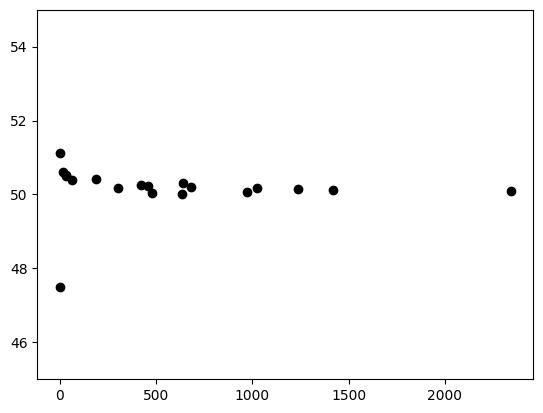

In [ ]:
plt.scatter(obs_val, obs_z, color='k', label='observations')#, s=3)
plt.ylim(45, 55)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Confidence interval calculation ---
def get_ci_bounds(chain, names, chain1, names1, z_plot, t_final, t_plot,
                  alpha, u1, u2, n_samples=500, ci=95):
    """
    Sample parameters from the chain and compute CI bounds on the solution.
    """
    lower_p = (100 - ci) / 2
    upper_p = 100 - lower_p

    # Pool both chains for each estimated parameter
    Da_samples    = np.concatenate([chain[:, names.index('Da')],
                                    chain1[:, names1.index('Da')]])
    kappa_samples = np.concatenate([chain[:, names.index('kappa')],
                                    chain1[:, names1.index('kappa')]])
    C_samples     = np.concatenate([chain[:, names.index('C')],
                                    chain1[:, names1.index('C')]])

    # Draw random samples
    idx = np.random.choice(len(Da_samples), size=n_samples, replace=False)
    solutions = []
    for i in idx:
        sol = B_funky(z_plot, t_final, u1, u2, alpha,
                      Da_samples[i], kappa_samples[i], C_samples[i], t_plot)
        solutions.append(sol)

    solutions = np.array(solutions)
    lower = np.percentile(solutions, lower_p, axis=0)
    upper = np.percentile(solutions, upper_p, axis=0)
    return lower, upper


# --- Estimated solution ---
alpha_est = alpha
Da_est    = np.mean(combichains[:, names.index('Da')])
C_est     = np.mean(combichains[:, names.index('C')])
kappa_est = np.mean(combichains[:, names.index('kappa')])
u1_est    = u1
u2_est    = u2

print(Da_est, C_est, kappa_est)

z_plot  = np.linspace(0, 150, 1500)
t_final = 70.0
t_plot  = np.linspace(0, t_final, 1000)

total_est = B_funky(z_plot, t_final, u1_est, u2_est, alpha_est,
                    Da_est, kappa_est, C_est, t_plot)

# Compute CI bounds
ci_lower, ci_upper = get_ci_bounds(chain, names, chain1, names1,
                                   z_plot, t_final, t_plot,
                                   alpha_est, u1_est, u2_est)

title_str = (
    f'α={alpha_est:.4f},  Da={Da_est:.4f},  κ={kappa_est:.4f},  '
    f'u1={u1_est:.4f},  u2={u2_est:.4f},  C={C_est:.4f}'
)


def make_panel(ax, xscale='linear', ylim=None, xlabel='Concentration'):
    """Helper to plot solution, CI band and observations on a given axis."""
    # CI shading
    ax.fill_betweenx(z_plot, ci_lower, ci_upper,
                     alpha=0.3, color='gray', label='95% CI')
    # Mean solution
    ax.plot(total_est, z_plot,
            label='A + B (estimated)', color='tab:blue')
    # CI edges
    ax.plot(ci_lower, z_plot,
            color='gray', linewidth=0.8, linestyle='--')
    ax.plot(ci_upper, z_plot,
            color='gray', linewidth=0.8, linestyle='--')
    # Observations
    ax.scatter(obs_val, obs_z,
               color='k', label='Observations', s=3, zorder=5)
    # Seabed
    ax.axhline(y=50, linestyle='--', color='gray', label='Seabed')
    ax.set_xlabel(xlabel)
    ax.set_xscale(xscale)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.invert_yaxis()
    ax.grid()
    ax.legend(fontsize=8)


# ---------------------------------------------------------------
# Figure 1: Full domain 0-150, log and linear
# ---------------------------------------------------------------
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

make_panel(axes1[0], xscale='log',
           xlabel='Concentration (log scale)')
axes1[0].set_ylabel('Depth (m)')
axes1[0].set_title('Log x-axis')

make_panel(axes1[1], xscale='linear',
           xlabel='Concentration (linear scale)')
axes1[1].set_title('Linear x-axis')

fig1.suptitle(f'Estimated solution — full domain (0–150 m)\n{title_str}',
              y=1.01)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()


# ---------------------------------------------------------------
# Figure 2: Zoomed 0-60 m, log and linear
# ---------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

make_panel(axes2[0], xscale='log',
           ylim=(0, 60),
           xlabel='Concentration (log scale)')
axes2[0].set_ylabel('Depth (m)')
axes2[0].set_title('Log x-axis')

make_panel(axes2[1], xscale='linear',
           ylim=(0, 60),
           xlabel='Concentration (linear scale)')
axes2[1].set_title('Linear x-axis')

fig2.suptitle(f'Estimated solution — zoomed (0–60 m)\n{title_str}',
              y=1.01)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# Figure 3: Zoomed 40-60 m, log and linear
# ---------------------------------------------------------------
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

make_panel(axes3[0], xscale='log',
           ylim=(48, 55),
           xlabel='Concentration (log scale)')
axes3[0].set_ylabel('Depth (m)')
axes3[0].set_title('Log x-axis')

make_panel(axes3[1], xscale='linear',
           ylim=(48, 55),
           xlabel='Concentration (linear scale)')
axes3[1].set_title('Linear x-axis')

fig3.suptitle(f'Estimated solution — zoomed (40–60 m)\n{title_str}',
              y=1.01)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# Source term A
# ---------------------------------------------------------------
A = C_est * np.exp(-(alpha_est / Da_est) * z_plot)
plt.figure(figsize=(6, 8))
plt.plot(A, z_plot, 'k-.', label='A (source)')
plt.gca().invert_yaxis()
plt.xlabel('Concentration')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(C_est * np.exp(-(alpha_est / Da_est) * 50))

9.25839412640072 127.4795190341697 0.09077839111812291


c:\Users\Træning 3\OneDrive - Roskilde Universitet\12. semester\Speciale - General\Numerik\Scripts\MCMC\it4\it4_anal_solver.py:16: RuntimeWarning: overflow encountered in exp
  b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))


NameError: name 'chain1' is not defined